<a href="https://colab.research.google.com/github/shreyoshi2304/RNN-Auditory/blob/main/Variability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

In [ ]:
def generate_spectrogram_data(n_samples=200, seq_len=80, n_freq=20):
    X = []
    Y = []

    for _ in range(n_samples):
        freq = np.random.uniform(2, 10)
        t = np.linspace(0, 1, seq_len)

        spec = np.zeros((seq_len, n_freq))

        for f_bin in range(n_freq):
            center = f_bin / n_freq * 10
            signal = np.sin(2 * np.pi * freq * t)

            weight = np.exp(-(center - freq)**2 / 2)
            spec[:, f_bin] = weight * signal

        spec += np.random.normal(0, 0.1, spec.shape)

        X.append(spec)
        Y.append(freq)

    return np.array(X), np.array(Y)


X, Y = generate_spectrogram_data()

X = torch.tensor(X, dtype=torch.float32)
Y = torch.tensor(Y, dtype=torch.float32)

print("Data shape:", X.shape)

Data shape: torch.Size([200, 80, 20])


In [ ]:
class AuditoryRNN(nn.Module):
    def __init__(self, input_size=20, hidden_size=40):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :]), out


class RateModel(nn.Module):
    def __init__(self, input_size=20):
        super().__init__()
        self.fc = nn.Linear(input_size, 1)

    def forward(self, x):
        x_mean = x.mean(dim=1)
        return self.fc(x_mean)


rnn_model = AuditoryRNN()
rate_model = RateModel()

In [ ]:
def train_model(model, X, Y, epochs=100):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    criterion = nn.MSELoss()

    for epoch in range(epochs):
        optimizer.zero_grad()

        if isinstance(model, AuditoryRNN):
            pred, _ = model(X)
        else:
            pred = model(X)

        loss = criterion(pred.squeeze(), Y)
        loss.backward()
        optimizer.step()

    return model


rnn_model = train_model(rnn_model, X, Y)
rate_model = train_model(rate_model, X, Y)

print("Training complete")

Training complete


In [ ]:
def test_variability(model, X, noise_std=0.2, trials=30):
    outputs = []

    for _ in range(trials):
        noisy_X = X + noise_std * torch.randn_like(X)

        with torch.no_grad():
            if isinstance(model, AuditoryRNN):
                pred, _ = model(noisy_X)
            else:
                pred = model(noisy_X)

        outputs.append(pred.numpy())

    outputs = np.array(outputs)

    # Mean + variance across trials
    mean_response = outputs.mean(axis=0)
    variability = outputs.var(axis=0)

    return mean_response, variability

In [ ]:
mean_rnn, var_rnn = test_variability(rnn_model, X)
mean_rate, var_rate = test_variability(rate_model, X)

print("Average variability (RNN):", var_rnn.mean())
print("Average variability (Rate):", var_rate.mean())

Average variability (RNN): 0.0027730954
Average variability (Rate): 0.008072507


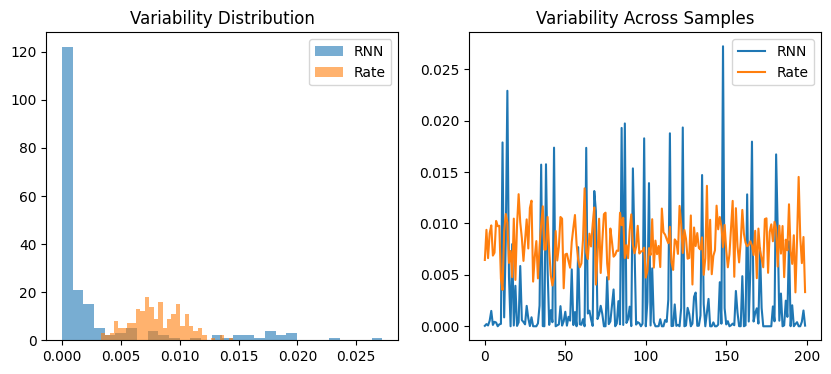

In [ ]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(var_rnn.flatten(), bins=30, alpha=0.6, label="RNN")
plt.hist(var_rate.flatten(), bins=30, alpha=0.6, label="Rate")
plt.title("Variability Distribution")
plt.legend()

plt.subplot(1,2,2)
plt.plot(var_rnn.mean(axis=1), label="RNN")
plt.plot(var_rate.mean(axis=1), label="Rate")
plt.title("Variability Across Samples")
plt.legend()

plt.show()

### Interpretation

The recurrent model exhibits lower variability under noisy inputs compared to the rate-based model.  
This suggests that temporal integration and recurrent dynamics stabilize representations,  
providing robustness to input noise, a key feature of auditory neural processing.